# Homopolymer Length QC: HipSTR Q by repeat length

Compare genotype confidence (**Q**) across homopolymer lengths at 1 bp resolution.

Each HipSTR VCF contributes one **Q score per cell × target** genotype call. The line plot shows the median Q at each length; the shaded band is the interquartile range (25th–75th percentile).

**Cohorts:**
- HCT116 library (2021–2023, pre-optimization): early NovaSeq SP benchmarking
- Msh2 mouse library (2025, optimized, RETrace2): current cohort after protocol improvements

**Length range:** capped at 25 bp for direct comparison. In the pre-optimization HCT116 library, genotype calls drop below ~1,000 beyond 25 bp (e.g. 961 at 26 bp, 46 at 30 bp), so median Q at those lengths is unstable. The optimized Msh2 library retains high call counts through 30 bp.

Only HipSTR VCFs are required.

In [24]:
import re

import matplotlib.pyplot as plt
import pandas as pd

LENGTH_RE = re.compile(r'_(\d+)x[ATGC]$')
MISSING_SAMPLE = '.:.:.:.:.:.:.:.:.:.:.:.:.:.:.:.'
MAX_LENGTH_BP = 25  # HCT116 has <1,000 genotype calls per length beyond 25 bp

COHORT_LABELS = {
    'HCT116_2023_pre-optimization': 'HCT116 library (2021–2023, pre-optimization)',
    'RETrace2_2025_optimized': 'Msh2 mouse library (2025, optimized, RETrace2)',
}

COHORT_COLORS = {
    'HCT116 library (2021–2023, pre-optimization)': '#D55E00',
    'Msh2 mouse library (2025, optimized, RETrace2)': '#0072B2',
}

VCF_PATHS = {
    'HCT116_2023_pre-optimization': [
        '/home/tony/Scratch/RETrace2/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/results_1nt12k10-14bp_500targets_minqual0/hipstr/20230117_HCT116_1nt12k10-14bp.vcf',
        '/home/tony/Scratch/RETrace2/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/results_1nt12k15-50bp_500targets_minqual0/hipstr/20230117_HCT116_1nt12k15-50bp.vcf',
    ],
    'RETrace2_2025_optimized': [
        '/home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/hipstr/2025_MSH2_female_combined.vcf',
    ],
}


def parse_vcf(vcf_path, cohort):
    records = []
    with open(vcf_path) as handle:
        for line in handle:
            if line.startswith('#'):
                continue
            parts = line.rstrip('\n').split('\t')
            match = LENGTH_RE.search(parts[2])
            if not match:
                continue
            length = int(match.group(1))
            if length > MAX_LENGTH_BP:
                continue
            for sample_field in parts[9:]:
                if sample_field == MISSING_SAMPLE:
                    continue
                fields = sample_field.split(':')
                if len(fields) < 3 or fields[2] == '.':
                    continue
                records.append({'cohort': cohort, 'length': length, 'Q': float(fields[2])})
    return pd.DataFrame(records)


def summarize_by_length(df):
    rows = []
    for (cohort, length), group in df.groupby(['cohort', 'length'], sort=True):
        rows.append({
            'cohort': cohort,
            'length': int(length),
            'n_calls': len(group),
            'median_Q': group['Q'].median(),
            'q25_Q': group['Q'].quantile(0.25),
            'q75_Q': group['Q'].quantile(0.75),
            'frac_Q_ge_0_9': (group['Q'] >= 0.9).mean(),
        })
    return pd.DataFrame(rows).sort_values(['cohort', 'length'])


def plot_q_lineplot(summary):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
    for cohort in summary['cohort'].unique():
        subset = summary[summary['cohort'] == cohort].sort_values('length')
        label = COHORT_LABELS[cohort]
        color = COHORT_COLORS[label]
        ax.plot(
            subset['length'],
            subset['median_Q'],
            marker='o',
            markersize=4,
            linewidth=1.8,
            color=color,
            label=label,
        )
        ax.fill_between(
            subset['length'],
            subset['q25_Q'],
            subset['q75_Q'],
            color=color,
            alpha=0.15,
            linewidth=0,
        )
    ax.set_title('HipSTR genotype confidence by homopolymer length')
    ax.set_xlabel('Homopolymer length (bp)')
    ax.set_ylabel('Genotype posterior probability (Q)')
    ax.set_xticks(range(10, MAX_LENGTH_BP + 1))
    ax.set_xlim(9.5, MAX_LENGTH_BP + 0.5)
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False, loc='lower left')
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig('hipstr_q_by_homopolymer_length.pdf', bbox_inches='tight')
    fig.savefig('hipstr_q_by_homopolymer_length.png', dpi=300, bbox_inches='tight')
    plt.show()

In [25]:
frames = []
for cohort, paths in VCF_PATHS.items():
    cohort_df = pd.concat([parse_vcf(path, cohort) for path in paths], ignore_index=True)
    frames.append(cohort_df)
    print(f"{COHORT_LABELS[cohort]}: {len(cohort_df):,} genotype calls")

calls = pd.concat(frames, ignore_index=True)
summary = summarize_by_length(calls)
summary

HCT116 library (2021–2023, pre-optimization): 116,954 genotype calls
Msh2 mouse library (2025, optimized, RETrace2): 4,014,648 genotype calls


,cohort,length,n_calls,median_Q,q25_Q,q75_Q,frac_Q_ge_0_9
0,HCT116_2023_pre-optimization,10,17949,1.00,0.65,1.0,0.659758
1,HCT116_2023_pre-optimization,11,12918,1.00,0.58,1.0,0.654281
2,HCT116_2023_pre-optimization,12,9598,1.00,0.50,1.0,0.629089
3,HCT116_2023_pre-optimization,13,7126,1.00,0.47,1.0,0.630789
4,HCT116_2023_pre-optimization,14,6539,1.00,0.49,1.0,0.646276
5,HCT116_2023_pre-optimization,15,17382,0.90,0.43,1.0,0.503337
6,HCT116_2023_pre-optimization,16,11798,0.89,0.40,1.0,0.499068
7,HCT116_2023_pre-optimization,17,7737,0.82,0.37,1.0,0.468140
8,HCT116_2023_pre-optimization,18,6735,0.80,0.36,1.0,0.449443
9,HCT116_2023_pre-optimization,19,4924,0.79,0.38,1.0,0.440902


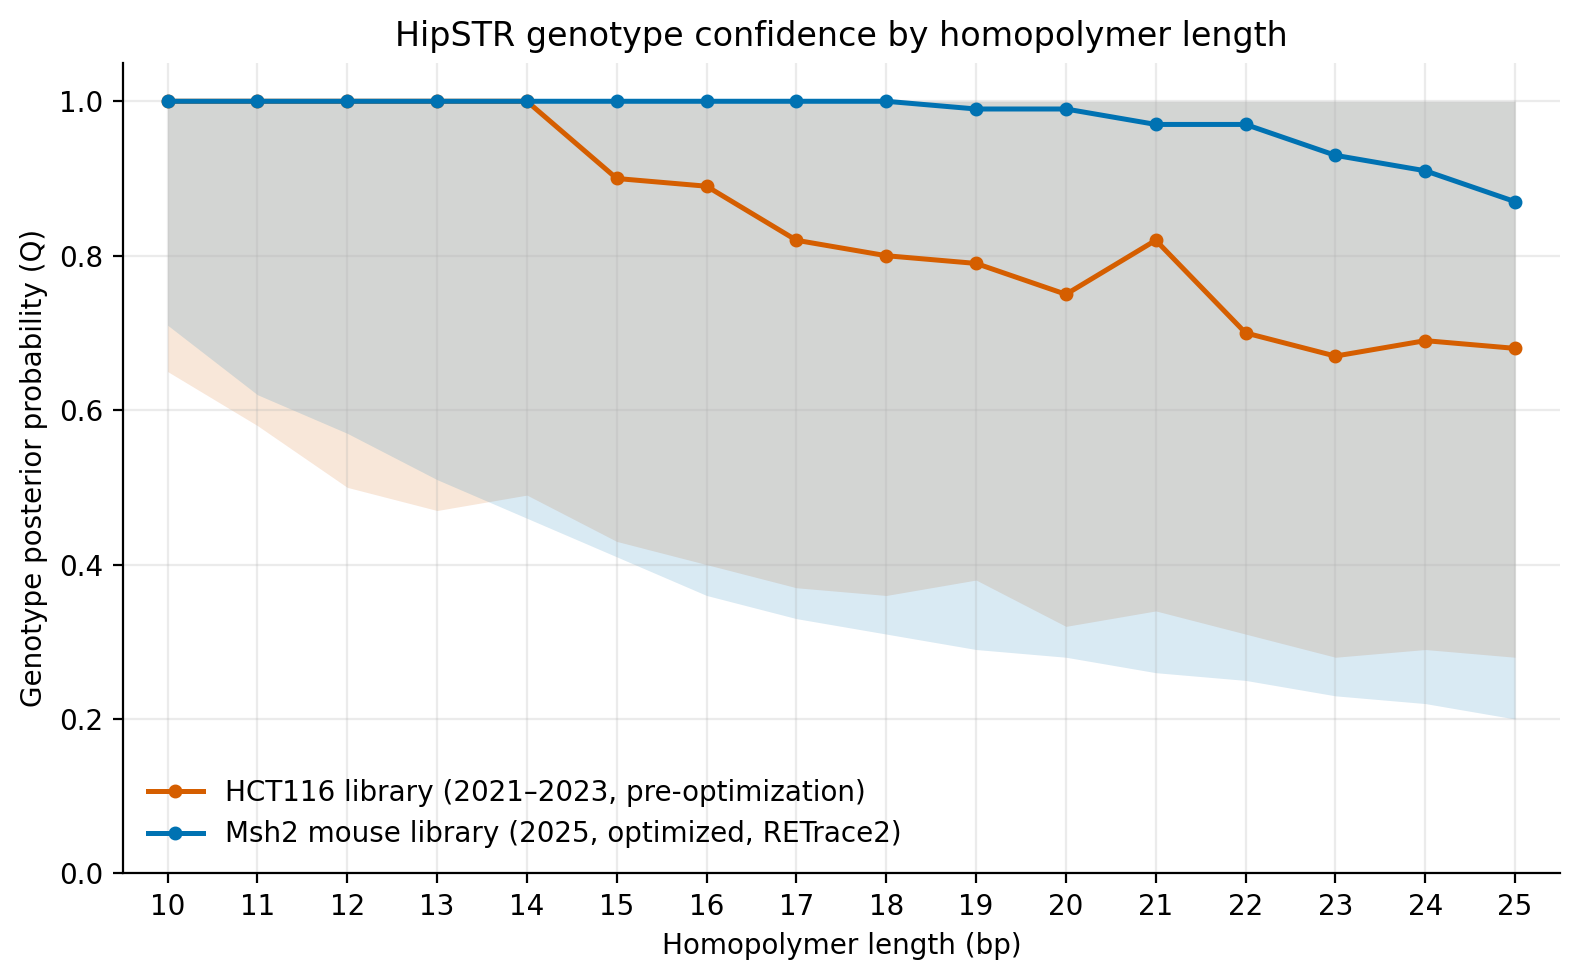

In [26]:
plot_q_lineplot(summary)

## Notes for interpretation

- **Q** is HipSTR's posterior probability for each cell × target genotype call.
- The line is the **median Q** across all calls at each homopolymer length; the shaded band is the **25th–75th percentile**.
- The comparison is capped at **25 bp** because the HCT116 pre-optimization library has fewer than ~1,000 genotype calls per length beyond 25 bp, making median Q unreliable at 26–30 bp (e.g. n = 46 at 30 bp).